<a href="https://colab.research.google.com/github/anyjamesokay/ugradthesis/blob/main/SDSwaveform_ecctest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
!apt-get update -qq
!apt-get install -y libgsl-dev

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libgsl-dev is already the newest version (2.7.1+dfsg-6ubuntu2).
0 upgraded, 0 newly installed, 0 to remove and 58 not upgraded.


In [20]:
!pip install gwosc gwpy pycbc corner sxs fastemriwaveforms teobresums gw-eccentricity scri polyrat

In [21]:
import scipy as sp
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Latex
import pandas as pd
import gw_eccentricity as egw
from polyrat import StabilizedSKRationalApproximation as rational_fit


In [22]:
def ecxxmaker(t0, theta, mode, window, showpoints):
    def ec22(fplus, fminus):
      iksi = (abs(fplus - fminus))/(fplus + fminus)
      psi = (1/3)*np.arctan2(np.sqrt(1-iksi**2), iksi)
      e_c = np.cos(psi) - np.sqrt(3)*np.sin(psi)
      return e_c

    def ec33(fplus, fminus):
      iksi = (abs(fplus - fminus))/(fplus + fminus)
      theta = (1/3)*np.arctan((1242*np.sqrt(3)/iksi)*(np.sqrt(35266176 - 31184003*iksi**2 - 3675129*iksi**4)/(15712542 + 1225043*iksi**2)))
      return (1/138)*(-107*iksi + np.sqrt(54648 + 11449*iksi)*np.cos(theta)-np.sqrt(163944 + 34347*iksi)*np.sin(theta))

    def ec44func(e):
      return (2*e*(6944-5700*e**2+261*e**4))/(8192-1513*e**2-3669*e**4)

    dt = abs(t0[1] - t0[0])
    #dtheta_dt = -sp.signal.savgol_filter(theta, window_length=100, polyorder=5, deriv=1, delta=dt)
    dtheta_dt = -np.gradient(theta, t0)
    dtheta_dt = sp.signal.savgol_filter(dtheta_dt, window_length=window, polyorder=3, delta=dt)
    fvalues = dtheta_dt / (2 * np.pi)
    #dfvalues = sp.signal.savgol_filter(fvalues, window_length=175, polyorder=3, deriv=1, delta=dt)
    dfvalues = np.gradient(fvalues, t0)
    dfvalues = sp.signal.savgol_filter(dfvalues, window_length=window, polyorder=3, delta=dt)
    zero_crossings = np.where(dfvalues[1:] * dfvalues[:-1] < 0)[0]
    zero_crossings2 = np.roll(zero_crossings, shift=1)
    zero_crossings3 = np.average(np.array([zero_crossings, zero_crossings2]), axis=0).astype(int)
    fplus = fvalues[zero_crossings]
    fminus = fvalues[zero_crossings2]
    iksi = (abs(fplus - fminus))/(fplus + fminus)
    if mode == 22:
      ee = ec22(fplus, fminus)
    elif mode == 33:
      ee = ec33(fplus, fminus)
    elif mode == 44:
      def ec44(e, iksi):
          return ec44func(e) - iksi
      ee = np.array([sp.optimize.root_scalar(ec44, args=(j,), x0=0.2, xtol = 1e-10).root for j in iksi])
    else: return 0

    timec = t0[zero_crossings3]
    ec_top = ee[1:-1:2]
    ec_bot = ee[2::2]
    timec_top = timec[1:-1:2]
    timec_bot = timec[2::2]
    ec_ave = np.average(np.array([ec_top, ec_bot]), axis =0)
    time_ave = np.average(np.array([timec_top, timec_bot]), axis =0)
    if showpoints: return timec_top, timec_bot, ec_top, ec_bot, time_ave, ec_ave
    else: return time_ave, ec_ave

def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

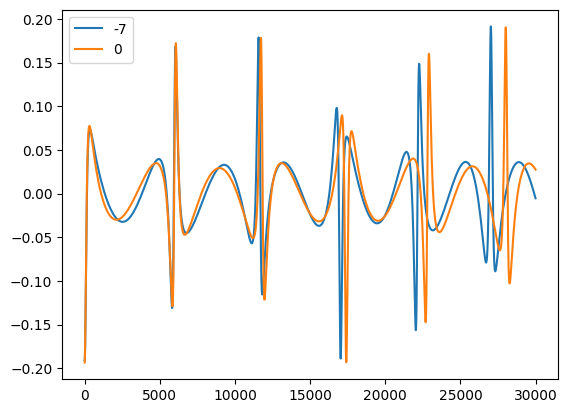

In [23]:
hpsds = pd.read_csv('plus_50_7_-7.csv', header=None, names=['t0', 'h+'])
hcsds = pd.read_csv('cross_50_7_-7.csv', header=None, names=['t0', 'h+'])
hpsds0 = pd.read_csv('plus_50_7_0.csv', header=None, names=['t0', 'h+'])
hcsds0 = pd.read_csv('cross_50_7_0.csv', header=None, names=['t0', 'h+'])
tp = hpsds['t0']
tc = hcsds['t0']
hpsd = hpsds['h+']
hcsd = hcsds['h+']
tp0 = hpsds0['t0']
tc0 = hcsds0['t0']
hpsd0 = hpsds0['h+']
hcsd0 = hcsds0['h+']
plt.plot(tp, hpsd, label="-7")
plt.plot(tp0, hpsd0, label="0")
plt.legend()

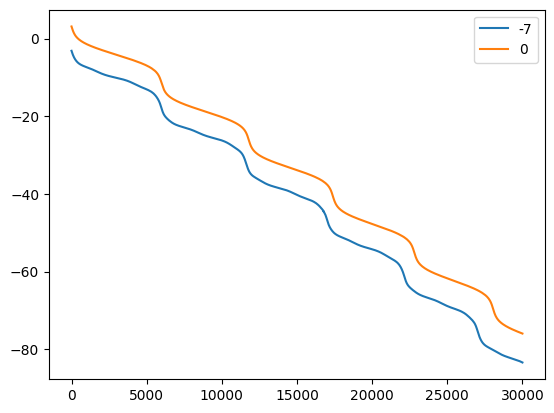

In [24]:
num, denom = 20, 20
#Arrays are not of the same size, might be best to interpolate now.
t10k = np.linspace(0, np.max(tp), 2000)
cplus = sp.interpolate.CubicSpline(tp, hpsd)
ccross = sp.interpolate.CubicSpline(tc, hcsd)
hp_int = cplus(t10k)
hc_int = ccross(t10k)
# ratp = ratc = rational_fit(num, denom)
# ratp.fit(tp.values.reshape(-1, 1), hpsd)
# ratc.fit(tc.values.reshape(-1, 1), hcsd)
# hp_int = ratp(t10k.reshape(-1, 1))
# hc_int = ratc(t10k.reshape(-1, 1))
thetasds = np.unwrap(np.arctan2(-hc_int, hp_int))
t100k = np.linspace(0, np.max(tp0), 2000)
cplus0 = sp.interpolate.CubicSpline(tp0, hpsd0)
ccross0 = sp.interpolate.CubicSpline(tc0, hcsd0)
hp_int0 = cplus0(t100k)
hc_int0 = ccross0(t100k)
# ratp0 = ratc0 = rational_fit(num, denom)
# ratp0.fit(tp0.values.reshape(-1, 1), hpsd0)
# ratc0.fit(tc0.values.reshape(-1, 1), hcsd0)
# hp_int0 = ratp(t100k.reshape(-1, 1))
# hc_int0 = ratc(t100k.reshape(-1, 1))
thetasds0 = np.unwrap(np.arctan2(-hc_int0, hp_int0))

# ddt = np.gradient(thetasds, t10k)
# ddt0 = np.gradient(thetasds0, t100k)
# ddt = sp.signal.savgol_filter(ddt, window_length=500, polyorder=3, delta=t10k[1]-t10k[0])
# ddt0 = sp.signal.savgol_filter(ddt0, window_length=500, polyorder=3, delta=t100k[1]-t100k[0])

plt.plot(t10k, thetasds, label="-7")
plt.plot(t100k, thetasds0, label="0")
plt.legend()

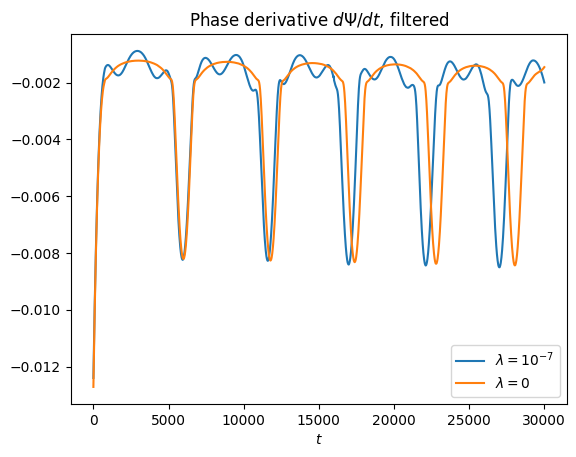

In [25]:
ddt = np.gradient(thetasds, t10k)
ddt0 = np.gradient(thetasds0, t100k)
ddt = sp.signal.savgol_filter(ddt, window_length=100, polyorder=3, delta=t10k[1]-t10k[0])
ddt0 = sp.signal.savgol_filter(ddt0, window_length=100, polyorder=3, delta=t100k[1]-t100k[0])
plt.plot(t10k, ddt, label=r"$\lambda=10^{-7}$")
plt.plot(t100k, ddt0, label=r"$\lambda=0$")
plt.title(r"Phase derivative $d\Psi / dt$, filtered")
plt.xlabel(r"$t$")
plt.legend()

In [26]:

#Arrays are not of the same size, might be best to interpolate now.
t100k = np.linspace(0, np.max(tp0), 10000)
cplus0 = sp.interpolate.CubicSpline(tp0, hpsd0)
ccross0 = sp.interpolate.CubicSpline(tc0, hcsd0)
hp_int0 = cplus0(t100k)
hc_int0 = ccross0(t100k)
thetasds0 = np.unwrap(np.arctan2(-hc_int0, hp_int0))
t_c, e_c = ecxxmaker(t10k, thetasds, 22, 200, False)
t_c = np.delete(t_c, 1)
e_c = np.delete(e_c, 1)
t_c0, e_c0 = ecxxmaker(t100k, thetasds0, 22, 100, False)
t_c0 = np.delete(t_c0, 1)
e_c0 = np.delete(e_c0, 1)

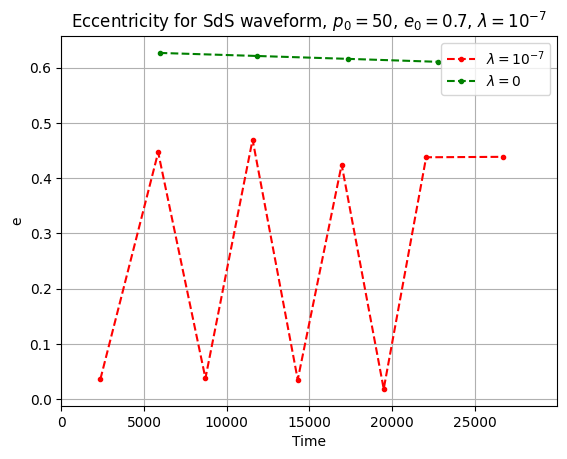

In [27]:
plt.plot(t_c, e_c, 'r--.', label=r"$\lambda=10^{-7}$")
plt.plot(t_c0, e_c0, 'g--.', label=r'$\lambda=0$')
plt.title(r"Eccentricity for SdS waveform, $p_0 = 50$, $e_0 = 0.7$, $\lambda = 10^{-7}$")
plt.legend()
plt.xlim(0, np.max(t10k))
# plt.ylim(0.6, 0.64)
plt.xlabel('Time')
plt.ylabel(r"e")
plt.grid(True)

In [28]:
help(egw.measure_eccentricity)

Help on function measure_eccentricity in module gw_eccentricity.gw_eccentricity:

measure_eccentricity(
    tref_in=None,
    fref_in=None,
    method='Amplitude',
    dataDict=None,
    num_orbits_to_exclude_before_merger=2,
    precessing=False,
    frame='inertial',
    debug_level=0,
    extra_kwargs=None
)
    Measure eccentricity and mean anomaly from a gravitational waveform.

    Eccentricity is measured using the GW frequency omega_gw(t) =
    d(phase_gw)/dt. Throughout this documentation, we will refer to phase_gw,
    omega_gw and amp_gw. For nonprecessing systems, these quantities are simply
    the corresponding values of the (2, 2) mode,

    amp_gw = amp22, phase_gw = phase22 and omega_gw = omega22.

    On the other hand, for precessing systems, we use Eq.(48) and (49) of
    arXiv:1701.00550 to define amp_gw and phase_gw. amp_gw [phase_gw] is
    defined using a symmetric [antisymmetric] combination of
    amplitude [phase] of (2, 2) and (2, -2) mode in the coprecessin

In [29]:
Asds = np.sqrt(hp_int**2 + hc_int**2)

tgw, e_gw, mea, gwec = egw.measure_eccentricity(
    tref_in=10000,
    method="AmplitudeFits",
    dataDict={
        "t": t10k,
        "amplm": {(2,2): Asds},
        "phaselm": {(2,2): -thetasds}
    }
)

plt.plot(tgw, e_gw)

Exception: data set too short.